In [1]:
# 使用RNAlocate处理3.20test set
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import normalize

In [2]:
# 使用3.20 test set进行测试，并且进行自助法抽样测试
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score, matthews_corrcoef
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import random
from Bio import SeqIO
import os 

In [3]:
def parse_fasta_to_dataframe(fasta_path):
    records = []
    with open(fasta_path, 'r') as file:
        name, tag, seq_lines = None, None, []
        for line in file:
            line = line.strip()
            if line.startswith('>'):
                if name:
                    sequence = ''.join(seq_lines)
                    records.append({'name': name, 'tag': tag, 'sequence': sequence})
                # 处理新的记录
                header = line[1:]  # 去掉'>'符号
                # 从header中提取name和tag（分割最后一个下划线）
                if '_' in header:
                    # 找到最后一个下划线的位置
                    last_underscore_index = header.rfind('_')
                    name = header[:last_underscore_index]  # 下划线之前的部分作为name
                    tag_str = header[last_underscore_index + 1:]  # 下划线之后的部分作为tag
                    try:
                        tag = int(tag_str)  # 将tag转换为整数
                    except ValueError:
                        tag = None  # 如果转换失败，设为None
                else:
                    name = header
                    tag = None
                seq_lines = []
            else:
                seq_lines.append(line)
        # 添加最后一条记录
        if name:
            sequence = ''.join(seq_lines)
            records.append({'name': name, 'tag': tag, 'sequence': sequence})
    
    return pd.DataFrame(records)

In [11]:
bootstrap_dir = '/lulabdata3/huangkeyun/zhangys/RNA_locator/benchmark_evaluation/RNAlocate/bootstrap_results'

bootstrap_results = {
    'Bootstrap': [],
    'AUROC': [],
    'AUPRC': [],
    'Accuracy': [],
    'Sensitivity': [],
    'Specificity': [],
    'F1 Score': [],
    'MCC': []
}

all_evaluate_dfs = []

import os
import re
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score, matthews_corrcoef, confusion_matrix

for i in range(1, 6):
    fasta_path = os.path.join(bootstrap_dir, f'bootstrap_set_{i}.fasta')
    csv_folder = os.path.join(bootstrap_dir, f'fasta{i}_pred')  # 更新为读取预测文件夹
    
    # 读取 fasta
    df = parse_fasta_to_dataframe(fasta_path)
    
    # 读取并合并文件夹下的多个 csv
    csv_files = [f for f in os.listdir(csv_folder) if f.endswith('.csv')]
    # 根据文件名中的数字进行排序，确保拆分的预测结果能按原始顺序拼接
    csv_files = sorted(csv_files, key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0)
    
    pred_dfs = []
    for csv_file in csv_files:
        csv_file_path = os.path.join(csv_folder, csv_file)
        # pandas 默认会将第一行作为列名处理
        pred_dfs.append(pd.read_csv(csv_file_path))
    
    # 纵向合并所有子 csv
    pred = pd.concat(pred_dfs, ignore_index=True)
    
    # 横向合并 fasta df 和 pred df
    evaluate_df = pd.concat([df, pred], axis=1)
    
    # 数据清洗与概率计算 (解析 Location 1: Score1 )
    split_cols = evaluate_df['Location 1: Score1'].astype(str).str.split(' : ', expand=True)
    loc_names = split_cols[0].str.lower()
    scores = split_cols[1].astype(float)
    
    # 包含 extracellular 或 exosome 视为预测为1，否则为0
    evaluate_df['prediction'] = loc_names.str.contains('extracellular|exosome', na=False).astype(int)
    
    # 将 score 转化为正类(EV)的 prob (如果预测负类，则正类概率应该为 1-score)
    evaluate_df['prob'] = np.where(evaluate_df['prediction'] == 1, scores, 1 - scores)
    
    # 动态命名为 evaluate_df_1, evaluate_df_2 等
    globals()[f'evaluate_df_{i}'] = evaluate_df
    all_evaluate_dfs.append(evaluate_df)
    
    print(f"Successfully loaded and merged evaluate_df_{i}")
    
    # 获取标签和指标计算需要的值
    y_true = evaluate_df['tag'].astype(int)
    y_pred = evaluate_df['prediction'].astype(int)
    y_prob = evaluate_df['prob'] 
    
    # 计算指标
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # 计算混淆矩阵并提取 Sensitivity 和 Specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    # 记录到字典中
    bootstrap_results['Bootstrap'].append(i)
    bootstrap_results['AUROC'].append(auroc)
    bootstrap_results['AUPRC'].append(auprc)
    bootstrap_results['Accuracy'].append(acc)
    bootstrap_results['Sensitivity'].append(sensitivity)
    bootstrap_results['Specificity'].append(specificity)
    bootstrap_results['F1 Score'].append(f1)
    bootstrap_results['MCC'].append(mcc)

# 将字典转换为 DataFrame 供绘图调用
df_metrics = pd.DataFrame(bootstrap_results)

print("\n=== 每个 Bootstrap 的性能 ===")
print(df_metrics.to_string(index=False))


Successfully loaded and merged evaluate_df_1
Successfully loaded and merged evaluate_df_2
Successfully loaded and merged evaluate_df_3
Successfully loaded and merged evaluate_df_4
Successfully loaded and merged evaluate_df_5

=== 每个 Bootstrap 的性能 ===
 Bootstrap    AUROC    AUPRC  Accuracy  Sensitivity  Specificity  F1 Score      MCC
         1 0.567164 0.546018    0.5725     0.980392     0.147959  0.700525 0.233213
         2 0.556573 0.517543    0.5450     0.984615     0.126829  0.678445 0.214816
         3 0.542825 0.522580    0.5350     0.985000     0.085000  0.679310 0.160591
         4 0.526486 0.550998    0.5575     0.976744     0.070270  0.703518 0.113076
         5 0.526806 0.486272    0.4925     0.962963     0.071090  0.641975 0.074571


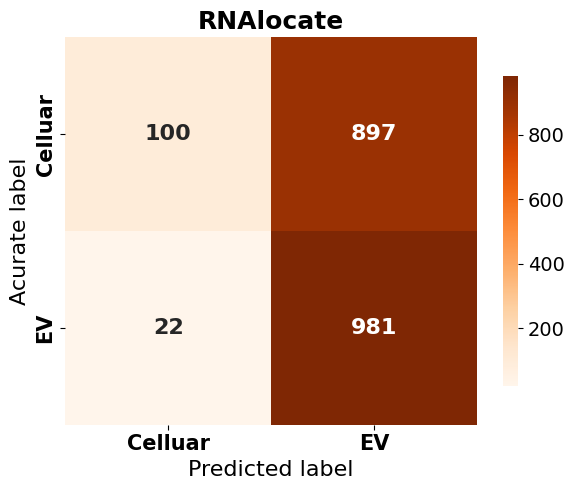

In [7]:
# 合并所有 5 次 bootstrap 的预测结果
merged_evaluate_df = pd.concat(all_evaluate_dfs, ignore_index=True)

# 计算总体混淆矩阵 (确保列的数据类型为整型以防报错)
cm = confusion_matrix(merged_evaluate_df['tag'].astype(int), merged_evaluate_df['prediction'].astype(int))

# 使用 seaborn 绘制混淆矩阵
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                 xticklabels=['Celluar', 'EV'], yticklabels=['Celluar', 'EV'],
                 annot_kws={'size': 16, 'weight': 'bold'},  # 调整内部数字的字体大小和加粗
                 cbar_kws={'shrink': 0.8})  # 可选：调整colorbar大小

plt.title('RNAlocate', fontsize=18, fontweight='bold')
plt.ylabel('Acurate label', fontsize=16)
plt.xlabel('Predicted label', fontsize=16)
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# 调整右侧colorbar图例数字的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # 调整colorbar刻度标签字体大小

plt.tight_layout()
plt.show()

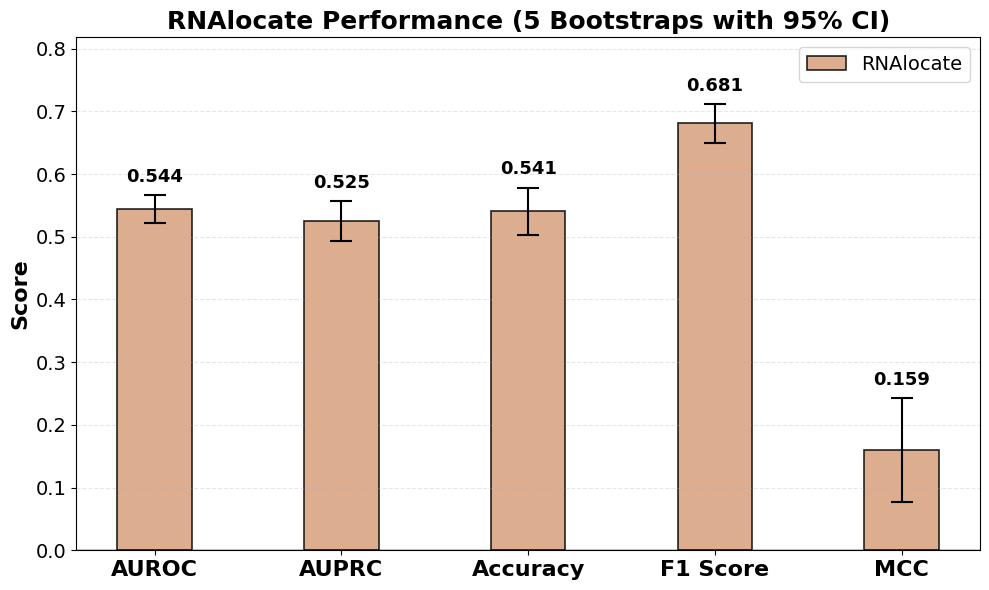

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

# 指标名称和模型列表
metrics = ['AUROC', 'AUPRC', 'Accuracy', 'F1 Score', 'MCC']
models_names = ['RNAlocate']  # 更新为 RNAlocate 模型

# 数据矩阵字典 (模型名称 -> 5个 Bootstrap x 5个 指标)
model_data_dict = {
    'RNAlocate': np.array([
        [0.567164, 0.546018, 0.5725, 0.700525, 0.233213],
        [0.556573, 0.517543, 0.5450, 0.678445, 0.214816],
        [0.542825, 0.522580, 0.5350, 0.679310, 0.160591],
        [0.526486, 0.550998, 0.5575, 0.703518, 0.113076],
        [0.526806, 0.486272, 0.4925, 0.641975, 0.074571]
    ])
}

# 暖色调配色（从浅到深）
warm_colors = ['#F8D7B4', '#F0C9A8', '#E8BB99', '#D89F7B', '#C8835D', '#B05930']

# 为模型分配颜色
model_colors = [warm_colors[3]] 

# 设置图形参数
fig, ax = plt.subplots(figsize=(10, 6))
n_metrics = len(metrics)
n_models = len(models_names)

# 根据模型数量动态计算柱子宽度和偏移
bar_width = 0.8 / (n_models + 0.5) if n_models > 1 else 0.4
x = np.arange(n_metrics)

max_y = 0  # 记录 Y 轴需要的最大高度
min_y = 0  # 记录 Y 轴需要的最小高度 (用于兼容负数)

# 循环遍历模型绘制分组柱子
for i, model_name in enumerate(models_names):
    data = model_data_dict[model_name]
    
    # 计算均值和 95% 置信区间 (95% CI)
    means = np.mean(data, axis=0)
    stds = np.std(data, axis=0, ddof=1)
    n = data.shape[0]
    cis = st.t.ppf(0.975, n-1) * (stds / np.sqrt(n))
    
    # 分组计算偏移量
    offset = (i - n_models/2 + 0.5) * bar_width
    
    # 绘制该模型在各个指标上的柱子
    bars = ax.bar(x + offset, means, bar_width, 
                  label=model_name, color=model_colors[i], 
                  edgecolor='black', linewidth=1.2, alpha=0.85,
                  yerr=cis, capsize=8, error_kw={'linewidth': 1.5, 'capthick': 1.5})
    
    # 在柱子上添加数值标签
    for j, bar in enumerate(bars):
        height = means[j]
        # 判断是正数还是负数，以便正确放置文本标签
        if height >= 0:
            current_top = height + cis[j]
            y_pos = current_top + 0.015
            va = 'bottom'
            if current_top > max_y: max_y = current_top
        else:
            current_bottom = height - cis[j]
            y_pos = current_bottom - 0.015
            va = 'top'
            if current_bottom < min_y: min_y = current_bottom

        ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{height:.3f}', ha='center', va=va, fontsize=13, fontweight='bold')

# 设置图形属性
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=16, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)

# 留足空间显示顶部和底部标签，对于包含负数的图，下限需要调整
ax.set_ylim(min_y * 1.5 if min_y < 0 else 0, max_y * 1.15) 

# 为了让负数柱子的零轴更明显
ax.axhline(0, color='black', linewidth=1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax.set_ylabel('Score', fontsize=16, fontweight='bold')
ax.set_title(f'{models_names[0]} Performance (5 Bootstraps with 95% CI)', fontsize=18, fontweight='bold')

# 只要有图例名就显示图例
ax.legend(fontsize=14, loc='upper right')

# 调整布局
plt.tight_layout()
plt.show()